In [137]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(1280, 960)


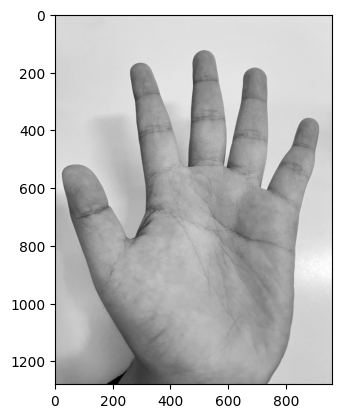

In [138]:
Tangan = cv2.imread('Telapaktangan.jpeg', cv2.IMREAD_GRAYSCALE)
print(Tangan.shape)
plt.imshow(Tangan, cmap = "gray")

In [139]:
def convolution(img, kernel):

    # ukuran kernel / kernel size
    size = kernel.shape[0]

    # ukuran padding / padding size
    pad_size = size // 2

    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)

    # dimensi gambar / image dimensions
    height, width = img.shape

    # loop baris / loop rows
    for i in range(height):

        # loop kolom / loop columns
        for j in range(width):

            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]

            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)

    # kembalikan gambar / return image
    return canvas

In [140]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

In [141]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    # kanvas kosong / empty canvas
    canvas = np. zeros_like(img, dtype=np. float32)
    # gabung gradien absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)
    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max (canvas)
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittX, prewittY)

In [142]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)
# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

In [143]:
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

In [144]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np. array([
    [1,  0],
    [0, -1],
], dtype=np. float32)
# kernel sobel sumbu y / y-axis sobel kernel
robertsY = np. array ([
    [0,  1],
    [-1, 0],
], dtype=np. float32)

In [145]:
def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):

            if(img[i,j] > batas):
                canvas[i,j] = 255

            elif(img[i,j] <= batas):
                canvas[i,j] = 0

    return canvas

In [146]:
def resized(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [147]:
def normalisasi(citra):
    c_min = np.min(citra)
    c_max = np.max(citra)
    normalized = (citra - c_min) / (c_max - c_min) if (c_max - c_min) != 0 else np.zeros_like(citra)
    return normalized

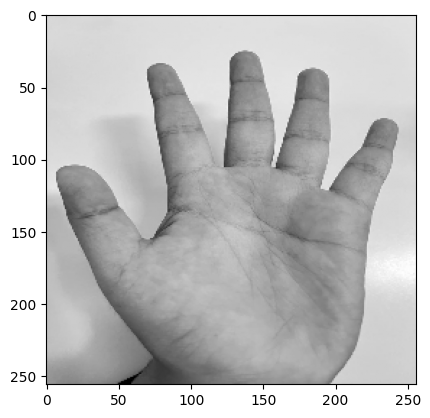

In [148]:
platResize = resized(Tangan, 256, 256)
platResize = np.array(platResize)
plt.imshow(platResize, cmap = 'gray')

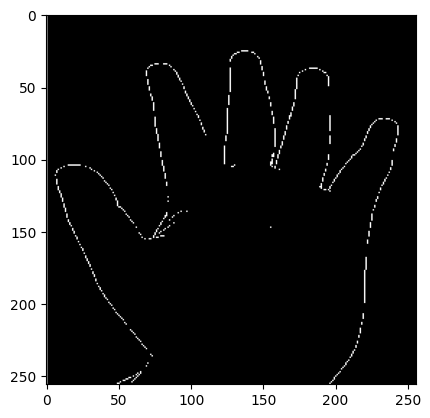

In [149]:
hasil_tepi=edge(Tangan, sobelX, sobelY)
Threshold25 = threshold(hasil_tepi, 25)
hasil_resize = resized(Threshold25, 256, 256)

plt.imshow(hasil_resize, cmap='gray')
plt.show()

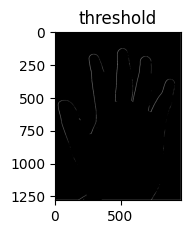

In [160]:
threshold = threshold(hasil_tepi, 60)

plt.subplot(2, 3, 4)
plt.imshow(threshold, cmap='gray')
plt.title('threshold')
plt.show()

In [150]:
def dilasi(image, kernel):
  height, width = image.shape
  k_height, k_width = kernel.shape
  center = k_height//2
  hasil = np.zeros((height, width))
  for i in range(center, height-center):
    for j in range(center, width-center):
      if image[i,j] == 255:
        for k in range(k_height):
          for l in range(k_width):
            if kernel[k,l] == 1:
              hasil[i+k-center,j+l-center] =255
  return hasil

In [151]:
def erosi(citra, mask):
    pad_t, pad_l = mask.shape[0] // 2, mask.shape[1] // 2
    citra_pad = np.pad(citra, ((pad_t, pad_t), (pad_l, pad_l)), mode='constant', constant_values=255)
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for r in range(pad_t, citra_pad.shape[0] - pad_t):
        for c in range(pad_l, citra_pad.shape[1] - pad_l):
            blok = citra_pad[r - pad_t:r + pad_t + 1, c - pad_l:c + pad_l + 1]
            if np.all(blok[mask == 1] == 255):
                hasil[r - pad_t, c - pad_l] = 255

    return hasil

In [152]:
def opening(img, kernel):
    hasil_erosi = erosi(img, kernel)
    hasil_opening = dilasi(hasil_erosi, kernel)
    return hasil_opening

def closing(img, kernel):
    hasil_dilasi = dilasi(img, kernel)
    hasil_closing = erosi(hasil_dilasi, kernel)
    return hasil_closing

In [153]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)

    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]

                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True

            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        # STEP 2
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]

                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True

            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

In [154]:
def thickening(img, kernel, iterasi=1):
  hasil = img.copy()
  for _ in range(iterasi):
    hasil = dilasi(hasil, kernel)
  return hasil

In [155]:
def gradient(citra, mask):

    dilasiHasil = dilasi(citra, mask)
    erosiHasil = erosi(citra, mask)

    gradientHasil = dilasiHasil - erosiHasil

    return gradientHasil

In [156]:
kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

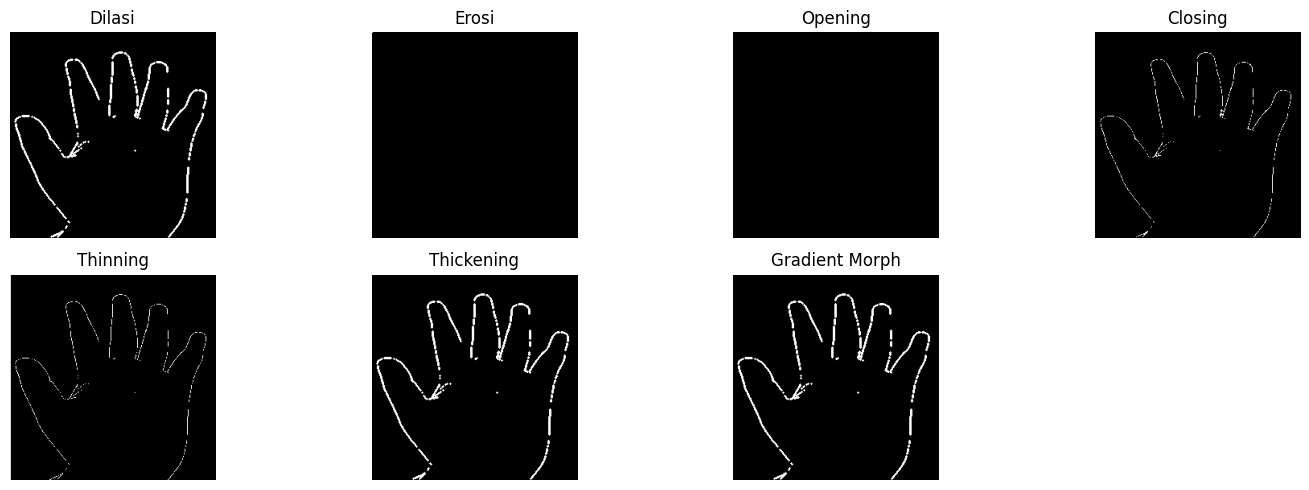

In [157]:
citra_input = hasil_resize

kernel = kernel_cross

hasil_dilasi    = dilasi(citra_input, kernel)
hasil_erosi     = erosi(citra_input, kernel)
hasil_opening   = opening(citra_input, kernel)
hasil_closing   = closing(citra_input, kernel)
hasil_thinning  = thinning(citra_input)
hasil_thickening = thickening(citra_input, kernel)
hasil_gradient  = gradient(citra_input, kernel)
hasil_gradient  = threshold(hasil_gradient, 1)

plt.figure(figsize=(15,5))

plt.subplot(2,4,1)
plt.imshow(hasil_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(hasil_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(hasil_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(hasil_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(hasil_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(hasil_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(hasil_gradient, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

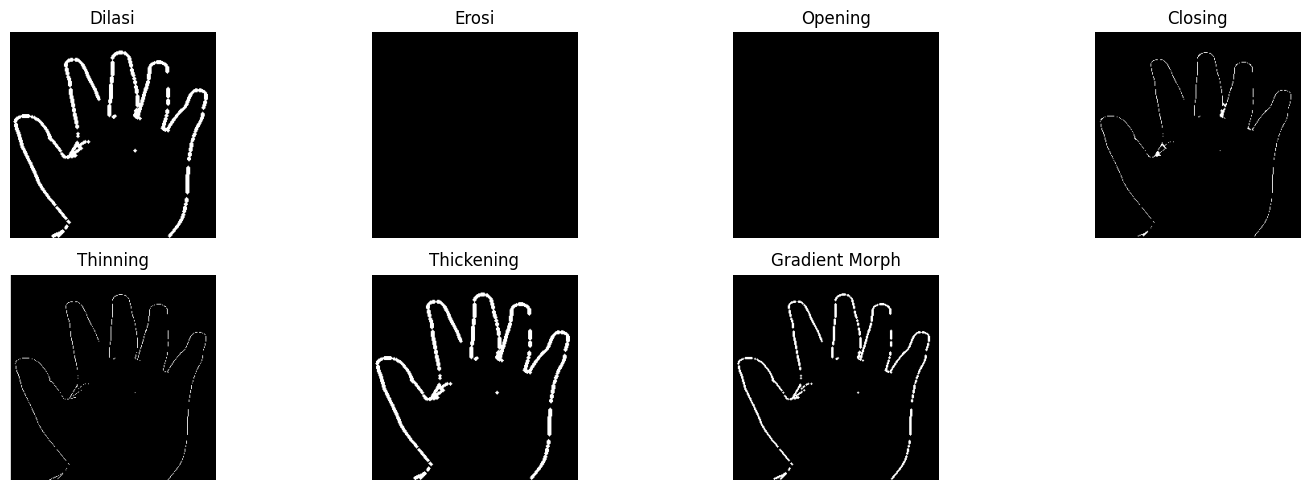

In [158]:
citra_input = hasil_resize

kernel = kernel_diamond

hasil_dilasi2    = dilasi(citra_input, kernel_diamond)
hasil_erosi2     = erosi(citra_input, kernel_diamond)
hasil_opening2   = opening(citra_input, kernel_diamond)
hasil_closing2   = closing(citra_input, kernel_diamond)
hasil_thinning2  = thinning(citra_input)
hasil_thickening2 = thickening(citra_input, kernel_diamond)
hasil_gradient2  = gradient(citra_input, kernel_diamond)
hasil_gradient2  = threshold(hasil_gradient, 30)

plt.figure(figsize=(15,5))

plt.subplot(2,4,1)
plt.imshow(hasil_dilasi2, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(hasil_erosi2, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(hasil_opening2, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(hasil_closing2, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(hasil_thinning2, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(hasil_thickening2, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(hasil_gradient2, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

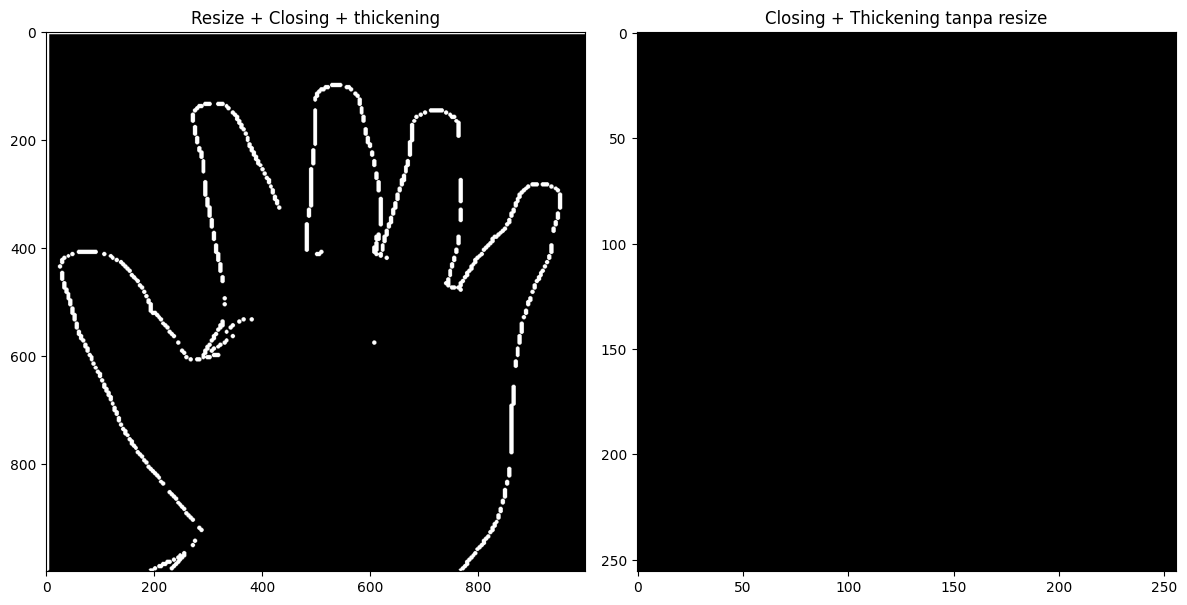

In [163]:
closingThickening = closing(hasil_thickening, kernel)
openingClosing = opening(hasil_closing, kernel)



platResize2 = resized(citra_input, 1000, 1000)
platResize2 = np.array(platResize2)
final = thickening(platResize2, kernel)
plt.figure(figsize=(12, 12))
plt.subplot(1,2,1)
plt.imshow(final, cmap='gray')
plt.title('Resize + Closing + thickening')
plt.subplot(1,2,2)
plt.imshow(openingClosing, cmap='gray')
plt.title('Closing + Thickening tanpa resize')
plt.tight_layout()